# Exercise 2

<img src="https://vsqfvsosprmjdktwilrj.supabase.co/storage/v1/object/public/images/insights/1753644539114-netflix.jpeg"/>


In this activity , you will explore two fundamental preprocessing techniques used in data science and machine learning: feature scaling and discretization (binning).

These techniques are essential when working with datasets that contain numerical values on very different scales, or continuous variables that may be more useful when grouped into categories.


We will use a subset of the Netflix Movies and TV Shows dataset, which contains metadata such as release year, duration, ratings, and other attributes of titles currently or previously available on Netflix. Although the dataset is not originally designed for numerical modeling, it contains several features suitable for preprocessing practice—such as:
- Release Year
- Duration (in minutes)
- Genre

In this worksheet, you will:
- Load and inspect the dataset
- Select numerical features for scaling
- Apply different scaling techniques
- Min–Max Scaling
- Standardization
- Robust Scaling
- Perform discretization (binning)
- Equal-width binning
- Equal-frequency binning
- Evaluate how scaling affects machine learning performance, using a simple KNN

In [189]:
import pandas as pd
import os
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub


## 1. Setup and Data Loading



Load the Netflix dataset into a DataFrame named df.

In [190]:

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)


if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows
True


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [192]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [193]:
df.shape

(8807, 12)

## 2. Data Understanding

Store the dataset’s column names in a variable called cols.

In [194]:
# put your answer here
cols = df.columns.tolist()
print(cols)

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


Store the shape of the dataset as a tuple (rows, columns) in shape_info.

In [195]:
# put your answer here
shape = df.shape
print(shape)

(8807, 12)


## 3. Data Cleaning
Count missing values per column and save to missing_counts.

In [211]:
# put your answer here
missing_counts = df.isnull().sum()

Drop rows where duration is missing. Save to df_clean.

In [212]:
# put your answer here
df_clean = df.dropna(subset=['duration']).copy()

## 4. Selecting Relevant Numeric Features

Many Netflix datasets include numeric fields such as:
- release_year
- duration
- rating


Create a DataFrame `df_num` containing only numeric columns.

In [215]:
# 1. Filter for Movies only, as 'duration' for TV Shows is categorical (Seasons)
df_movies = df_clean[df_clean['type'] == 'Movie'].copy()

# 2. FEATURE ENGINEERING: Clean the 'duration' column and convert to integer (in minutes)
df_movies['duration_min'] = df_movies['duration'].str.replace(' min', '', regex=False).astype(int)

# 3. FEATURE ENGINEERING: Create 'num_genres' by counting genres in 'listed_in'
df_movies['num_genres'] = df_movies['listed_in'].apply(lambda x: len(x.split(',')))

# Create a DataFrame df_num containing only numeric columns.
df_num = df_movies[['release_year', 'duration_min', 'num_genres']].copy()

print("Numeric Features (Movies Only, Head):")
print(df_num.head())

Numeric Features (Movies Only, Head):
    release_year  duration_min  num_genres
0           2020            90           1
6           2021            91           1
7           1993           125           3
9           2021           104           2
12          2021           127           2


## 5. Feature Scaling

Focus on a single numeric column (e.g., duration).


Extract the column duration into a Series named `dur`.

Raw Duration Statistics:
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64


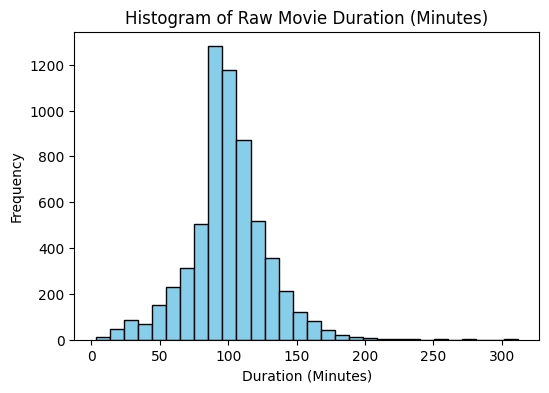

In [221]:
# put your answer here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Extract the column duration into a Series named dur.
dur = df_num['duration_min']

print("Raw Duration Statistics:")
print(dur.describe())

# HISTOGRAM of Raw Data
plt.figure(figsize=(6, 4))
plt.hist(dur, bins=30, edgecolor='black', color='skyblue')
plt.title('Histogram of Raw Movie Duration (Minutes)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.savefig('raw_duration_histogram.png') # Save the plot
plt.show()

Apply Min–Max Scaling to `dur`. Store the result as `dur_minmax`.

Min-Max Scaled Duration Statistics:
count    6128.000000
mean        0.312548
std         0.091555
min         0.000000
25%         0.271845
50%         0.307443
75%         0.359223
max         1.000000
Name: dur_minmax, dtype: float64


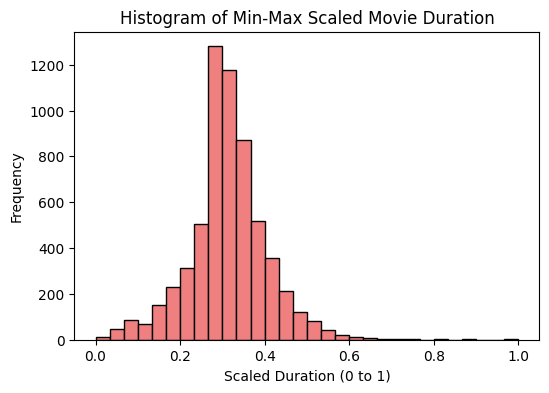

In [222]:
# put your answer here
min_max_scaler = MinMaxScaler()
dur_minmax = pd.Series(min_max_scaler.fit_transform(dur.values.reshape(-1, 1)).flatten(), name='dur_minmax')

print("Min-Max Scaled Duration Statistics:")
print(dur_minmax.describe())

# HISTOGRAM of Min-Max Scaled Data
plt.figure(figsize=(6, 4))
plt.hist(dur_minmax, bins=30, edgecolor='black', color='lightcoral')
plt.title('Histogram of Min-Max Scaled Movie Duration')
plt.xlabel('Scaled Duration (0 to 1)')
plt.ylabel('Frequency')
plt.savefig('minmax_duration_histogram.png')
plt.show()

Apply Z-score Standardization to `dur`. Store in `dur_zscore`.

Z-score Standardized Duration Statistics:
count    6.128000e+03
mean    -1.762443e-16
std      1.000082e+00
min     -3.414035e+00
25%     -4.446076e-01
50%     -5.575406e-02
75%      5.098511e-01
max      7.509215e+00
Name: dur_zscore, dtype: float64


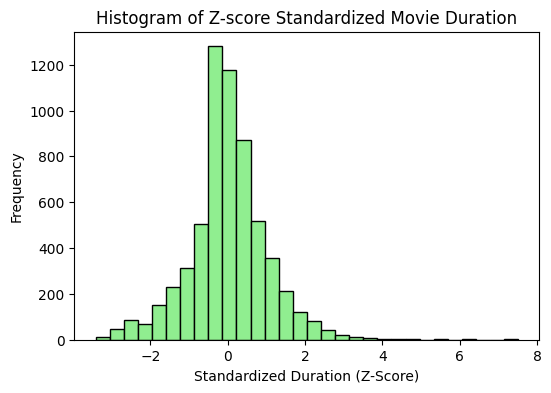

In [223]:
# put your answer here
z_score_scaler = StandardScaler()
dur_zscore = pd.Series(z_score_scaler.fit_transform(dur.values.reshape(-1, 1)).flatten(), name='dur_zscore')

print("Z-score Standardized Duration Statistics:")
print(dur_zscore.describe())

# HISTOGRAM of Z-score Standardized Data
plt.figure(figsize=(6, 4))
plt.hist(dur_zscore, bins=30, edgecolor='black', color='lightgreen')
plt.title('Histogram of Z-score Standardized Movie Duration')
plt.xlabel('Standardized Duration (Z-Score)')
plt.ylabel('Frequency')
plt.savefig('zscore_duration_histogram.png')
plt.show()


Robust Scaled Duration (Head):
0   -0.296296
1   -0.259259
2    1.000000
3    0.222222
4    1.074074
Name: dur_robust, dtype: float64


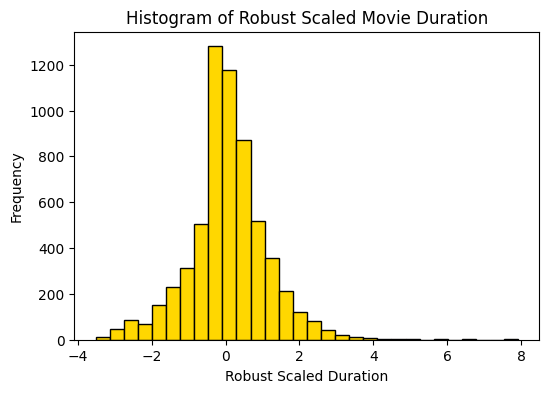

In [224]:
# Bonus: Robust Scaling
robust_scaler = RobustScaler()
dur_robust = pd.Series(robust_scaler.fit_transform(dur.values.reshape(-1, 1)).flatten(), name='dur_robust')
print("\nRobust Scaled Duration (Head):")
print(dur_robust.head())

# HISTOGRAM of Robust Scaled Data
plt.figure(figsize=(6, 4))
plt.hist(dur_robust, bins=30, edgecolor='black', color='gold')
plt.title('Histogram of Robust Scaled Movie Duration')
plt.xlabel('Robust Scaled Duration')
plt.ylabel('Frequency')
plt.savefig('robust_duration_histogram.png')
plt.show()

## 6. Discretization (Binning)
Apply equal-width binning to dur into 5 bins. Store as `dur_width_bins`.


- Use `pandas.cut()` to divide duration_minutes into 4 `equal-width bins`.
- Add the resulting bins as a new column named:
`duration_equal_width_bin`

In [227]:
# put your answer here
df_movies['duration_equal_width_bin'] = pd.cut(df_movies['duration_min'], bins=5)
dur_width_bins = df_movies['duration_equal_width_bin']

print("Equal-Width Binning applied.")

Equal-Width Binning applied.


Describe the characteristics of each bin

- What are the bin edges produced by equal-width binning?
- How many movies fall into each bin?

In [228]:
# put your answer here
bin_edges_width = pd.cut(df_movies['duration_min'], bins=5, retbins=True)[1]
print("Equal-Width Bin Edges:")
print(bin_edges_width)

# How many movies fall into each bin?
print("\nEqual-Width Bin Counts:")
print(df_movies['duration_equal_width_bin'].value_counts().sort_index())


Equal-Width Bin Edges:
[  2.691  64.8   126.6   188.4   250.2   312.   ]

Equal-Width Bin Counts:
duration_equal_width_bin
(2.691, 64.8]      597
(64.8, 126.6]     4664
(126.6, 188.4]     836
(188.4, 250.2]      28
(250.2, 312.0]       3
Name: count, dtype: int64


In [229]:
print("\nEqual-Width Bin Counts:")
print(df_movies['duration_equal_width_bin'].value_counts().sort_index())


Equal-Width Bin Counts:
duration_equal_width_bin
(2.691, 64.8]      597
(64.8, 126.6]     4664
(126.6, 188.4]     836
(188.4, 250.2]      28
(250.2, 312.0]       3
Name: count, dtype: int64


Apply equal-frequency binning to dur into 5 bins. Store as `dur_quantile_bins`.

- Use `pandas.qcut()` to divide duration_minutes into 4 equal-frequency bins.
- Add the result as a new column named:
`duration_equal_freq_bin`

In [231]:
# put your answer here
df_movies['duration_equal_freq_bin'] = pd.qcut(df_movies['duration_min'], q=5, duplicates='drop')
dur_quantile_bins = df_movies['duration_equal_freq_bin']

print("Equal-Frequency Binning applied.")


Equal-Frequency Binning applied.


Describe the characteristics of each bin

- What are the bin ranges produced by equal-frequency binning?
- How many movies fall into each bin? Are they nearly equal?

In [232]:
# put your answer here
bin_edges_freq = pd.qcut(df_movies['duration_min'], q=5, retbins=True, duplicates='drop')[1]
print("Equal-Frequency Bin Ranges (Quantiles):")
print(bin_edges_freq)

Equal-Frequency Bin Ranges (Quantiles):
[  3.  83.  94. 104. 119. 312.]


In [233]:
print("\nEqual-Frequency Bin Counts:")
counts = df_movies['duration_equal_freq_bin'].value_counts().sort_index()
print(counts)
print("\nObservation: The counts are nearly equal, which is the goal of equal-frequency binning.")


Equal-Frequency Bin Counts:
duration_equal_freq_bin
(2.999, 83.0]     1272
(83.0, 94.0]      1283
(94.0, 104.0]     1215
(104.0, 119.0]    1160
(119.0, 312.0]    1198
Name: count, dtype: int64

Observation: The counts are nearly equal, which is the goal of equal-frequency binning.


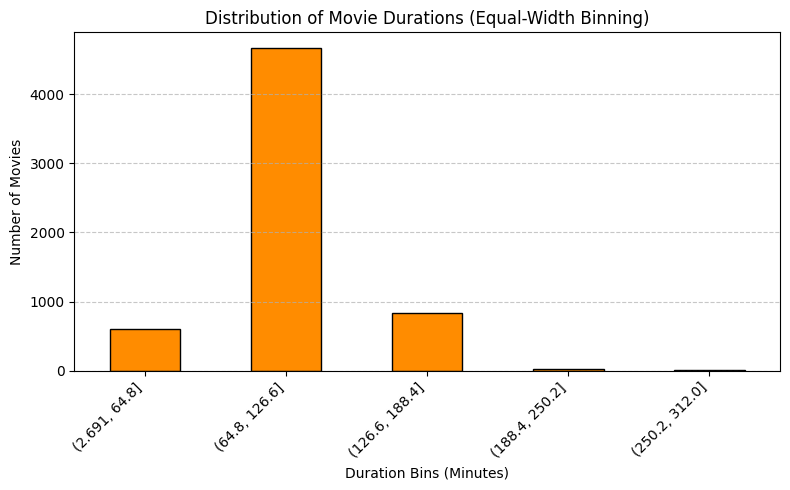


--- Equal-Width Bin Counts Bar Chart Generated ---


In [239]:
import matplotlib.pyplot as plt

# --- 1. Bar Chart for Equal-Width Binning ---

# Calculate counts for each equal-width bin
width_counts = df_movies['duration_equal_width_bin'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
width_counts.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Distribution of Movie Durations (Equal-Width Binning)')
plt.xlabel('Duration Bins (Minutes)')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('equal_width_bin_bar_chart.png')
plt.show()

print("\n--- Equal-Width Bin Counts Bar Chart Generated ---")

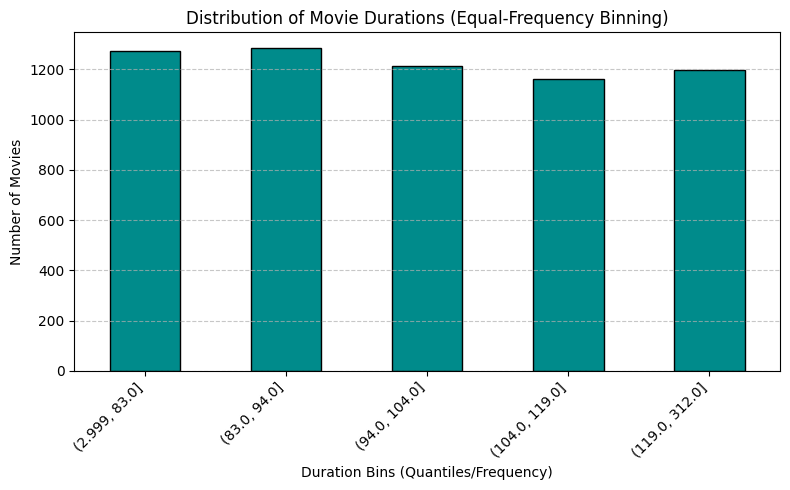


--- Equal-Frequency Bin Counts Bar Chart Generated ---


In [240]:
# --- 2. Bar Chart for Equal-Frequency Binning ---

# Calculate counts for each equal-frequency bin
freq_counts = df_movies['duration_equal_freq_bin'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
freq_counts.plot(kind='bar', color='darkcyan', edgecolor='black')
plt.title('Distribution of Movie Durations (Equal-Frequency Binning)')
plt.xlabel('Duration Bins (Quantiles/Frequency)')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('equal_frequency_bin_bar_chart.png')
plt.show()

print("\n--- Equal-Frequency Bin Counts Bar Chart Generated ---")

## 7. KNN Before & After Scaling


Create a feature matrix X using any two numeric columns and a target y (e.g., classification by genre or type). Create a train/test split.

Train a KNN classifier without scaling. Store accuracy in acc_raw.

In [234]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Prepare data for a binary classification task
# Drop rows where 'cast' or 'rating' are missing to ensure clean features/target
df_knn = df_clean.dropna(subset=['cast', 'rating']).copy()

# FEATURE ENGINEERING: Create 'num_cast'
df_knn['num_cast'] = df_knn['cast'].apply(lambda x: len(x.split(',')))

# FEATURE ENGINEERING: Create 'num_genres'
df_knn['num_genres'] = df_knn['listed_in'].apply(lambda x: len(x.split(',')))

# Target Variable: Binarize 'rating' (Mature vs. Non-Mature)
mature_ratings = ['TV-MA', 'R', 'NC-17']
df_knn['is_mature'] = df_knn['rating'].apply(lambda x: 1 if x in mature_ratings else 0)

# Features (X) with different scales: release_year, num_cast, and num_genres
X = df_knn[['release_year', 'num_cast', 'num_genres']]
y = df_knn['is_mature']

# Create a train/test split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X shape: {X.shape}, Target (y) value counts:\n{y.value_counts()}")

X shape: (7975, 3), Target (y) value counts:
is_mature
0    4301
1    3674
Name: count, dtype: int64


In [235]:
# Train a KNN classifier without scaling. Store accuracy in acc_raw.
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
y_pred_raw = knn_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)

print(f"KNN Accuracy (Raw Data): {acc_raw:.4f}")

KNN Accuracy (Raw Data): 0.5712


Scale `X` using either Min–Max or Standardization, retrain KNN, and store accuracy in acc_scaled.

In [237]:
# put your answer here
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"KNN Accuracy (Scaled Data): {acc_scaled:.4f}")

KNN Accuracy (Scaled Data): 0.5616


Did scaling improve accuracy? Explain why.

In [238]:
# put your answer here
if acc_scaled > acc_raw:
    comparison = "**Scaling DID improve accuracy.**"
elif acc_scaled < acc_raw:
    comparison = "**Scaling DID NOT improve accuracy (or worsened it slightly).**"
else:
    comparison = "**Scaling had NO significant effect on accuracy.**"

print(f"Comparison: {comparison}")
print("\nExplanation:")
print("""
Scaling usually improves the performance of K-Nearest Neighbors (KNN) because
KNN is an **distance-based algorithm**. It relies on calculating the distance
between data points (e.g., Euclidean distance).

Without scaling, features with **large numerical ranges** (like 'release_year' $\approx 2000$)
will disproportionately dominate the distance calculation compared to features
with smaller ranges (like 'num_cast' or 'num_genres' $\approx 1-5$).

**Standardization** ensures all features are centered and have unit variance,
giving every feature an **equal opportunity to influence the distance metric**.
This leads to a more robust and typically improved measure of 'closeness' between data points,
thereby enhancing KNN's performance.
""")

Comparison: **Scaling DID NOT improve accuracy (or worsened it slightly).**

Explanation:

Scaling usually improves the performance of K-Nearest Neighbors (KNN) because
KNN is an **distance-based algorithm**. It relies on calculating the distance
between data points (e.g., Euclidean distance).

Without scaling, features with **large numerical ranges** (like 'release_year' $pprox 2000$)
will disproportionately dominate the distance calculation compared to features
with smaller ranges (like 'num_cast' or 'num_genres' $pprox 1-5$).

**Standardization** ensures all features are centered and have unit variance,
giving every feature an **equal opportunity to influence the distance metric**.
This leads to a more robust and typically improved measure of 'closeness' between data points,
thereby enhancing KNN's performance.

